In [2]:
from pyspark.sql import SparkSession

# Start a Spark session
spark = SparkSession.builder.config("spark.driver.host", "localhost").appName("JobPostingsAnalysis").getOrCreate()
spark.catalog.clearCache()

# Load the CSV file into a Spark DataFrame
df = spark.read.option("header", "true").option("inferSchema", "true").option(
    "multiLine", "true").option("escape", "\"").csv("data/lightcast_job_postings.csv")

# Register the DataFrame as a temporary SQL view
df.createOrReplaceTempView("job_postings")

# Show Schema and Sample Data
print("---This is Diagnostic check, No need to print it in the final doc---")

# comment the lines below when rendering the submission
df.printSchema()
df.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/27 16:24:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/27 16:24:53 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


---This is Diagnostic check, No need to print it in the final doc---
root
 |-- ID: string (nullable = true)
 |-- LAST_UPDATED_DATE: string (nullable = true)
 |-- LAST_UPDATED_TIMESTAMP: timestamp (nullable = true)
 |-- DUPLICATES: integer (nullable = true)
 |-- POSTED: string (nullable = true)
 |-- EXPIRED: string (nullable = true)
 |-- DURATION: integer (nullable = true)
 |-- SOURCE_TYPES: string (nullable = true)
 |-- SOURCES: string (nullable = true)
 |-- URL: string (nullable = true)
 |-- ACTIVE_URLS: string (nullable = true)
 |-- ACTIVE_SOURCES_INFO: string (nullable = true)
 |-- TITLE_RAW: string (nullable = true)
 |-- BODY: string (nullable = true)
 |-- MODELED_EXPIRED: string (nullable = true)
 |-- MODELED_DURATION: integer (nullable = true)
 |-- COMPANY: integer (nullable = true)
 |-- COMPANY_NAME: string (nullable = true)
 |-- COMPANY_RAW: string (nullable = true)
 |-- COMPANY_IS_STAFFING: boolean (nullable = true)
 |-- EDUCATION_LEVELS: string (nullable = true)
 |-- EDUCATIO

+--------------------+-----------------+----------------------+----------+--------+---------+--------+--------------------+--------------------+--------------------+-----------+-------------------+--------------------+--------------------+---------------+----------------+--------+--------------------+-----------+-------------------+----------------+---------------------+-------------+-------------------+-------------+------------------+---------------+--------------------+--------------------+--------------------+-------------+------+-----------+----------------+-------------------+---------+-----------+--------------------+--------------------+-------------+------+--------------+-----+--------------------+-----+----------+---------------+--------------------+---------------+--------------------+------------+--------------------+------------+--------------------+------+--------------------+------+--------------------+------+--------------------+------+--------------------+------+------

In [3]:
from pyspark.sql.functions import monotonically_increasing_id

companies_df = df.select(
    "COMPANY",
    "COMPANY_NAME",
    "COMPANY_RAW",
    "COMPANY_IS_STAFFING"
).distinct()

# Create primary key
companies_df = companies_df.withColumn(
    "COMPANY_ID",
    monotonically_increasing_id()
)

# Reorder columns
companies_df = companies_df.select(
    "COMPANY_ID",
    "COMPANY",
    "COMPANY_NAME",
    "COMPANY_RAW",
    "COMPANY_IS_STAFFING"
)

# Register SQL table
companies_df.createOrReplaceTempView("companies")

companies_df.show(5)

+----------+--------+--------------------+--------------------+-------------------+
|COMPANY_ID| COMPANY|        COMPANY_NAME|         COMPANY_RAW|COMPANY_IS_STAFFING|
+----------+--------+--------------------+--------------------+-------------------+
|         0|35247729|               Crowe|               Crowe|              false|
|         1|39461288|The Devereux Foun...|The Devereux Foun...|              false|
|         2|40008275|      Elder Research|      Elder Research|              false|
|         3|37060425|            NTT DATA|        NTT DATA Inc|              false|
|         4|40882284|Frederick Nationa...|Frederick Nationa...|              false|
+----------+--------+--------------------+--------------------+-------------------+
only showing top 5 rows


In [4]:
industries_df = df.select(
    "NAICS_2022_6",
    "NAICS_2022_6_NAME",
    "SOC_5",
    "SOC_5_NAME",
    "LOT_SPECIALIZED_OCCUPATION_NAME",
    "LOT_OCCUPATION_GROUP"
).distinct()

industries_df = industries_df.withColumn(
    "INDUSTRY_ID",
    monotonically_increasing_id()
)

industries_df = industries_df.select(
    "INDUSTRY_ID",
    "NAICS_2022_6",
    "NAICS_2022_6_NAME",
    "SOC_5",
    "SOC_5_NAME",
    "LOT_SPECIALIZED_OCCUPATION_NAME",
    "LOT_OCCUPATION_GROUP"
)

industries_df.createOrReplaceTempView("industries")

industries_df.show(5)

+-----------+------------+--------------------+-------+---------------+-------------------------------+--------------------+
|INDUSTRY_ID|NAICS_2022_6|   NAICS_2022_6_NAME|  SOC_5|     SOC_5_NAME|LOT_SPECIALIZED_OCCUPATION_NAME|LOT_OCCUPATION_GROUP|
+-----------+------------+--------------------+-------+---------------+-------------------------------+--------------------+
|          0|      424490|Other Grocery and...|15-2051|Data Scientists|            SAP Analyst / Admin|                2310|
|          1|      562111|Solid Waste Colle...|15-2051|Data Scientists|           Oracle Consultant...|                2310|
|          2|      457110|Gasoline Stations...|15-2051|Data Scientists|           Oracle Consultant...|                2310|
|          3|      334111|Electronic Comput...|15-2051|Data Scientists|           Oracle Consultant...|                2310|
|          4|      621320|Offices of Optome...|15-2051|Data Scientists|           General ERP Analy...|                2310|


In [5]:
locations_df = df.select(
    "LOCATION",
    "CITY_NAME",
    "STATE_NAME",
    "COUNTY_NAME",
    "MSA",
    "MSA_NAME"
).distinct()

locations_df = locations_df.withColumn(
    "LOCATION_ID",
    monotonically_increasing_id()
)

locations_df = locations_df.select(
    "LOCATION_ID",
    "LOCATION",
    "CITY_NAME",
    "STATE_NAME",
    "COUNTY_NAME",
    "MSA",
    "MSA_NAME"
)

locations_df.createOrReplaceTempView("locations")

locations_df.show(5)

+-----------+--------------------+------------------+----------+-----------+-----+--------------------+
|LOCATION_ID|            LOCATION|         CITY_NAME|STATE_NAME|COUNTY_NAME|  MSA|            MSA_NAME|
+-----------+--------------------+------------------+----------+-----------+-----+--------------------+
|          0|{\n  "lat": 24.55...|      Key West, FL|   Florida| Monroe, FL|28580|        Key West, FL|
|          1|{\n  "lat": 41.62...|     Urbandale, IA|      Iowa|   Polk, IA|19780|Des Moines-West D...|
|          2|{\n  "lat": 37.20...|   Springfield, MO|  Missouri| Greene, MO|44180|     Springfield, MO|
|          3|{\n  "lat": 40.74...|[Unknown City], NJ|New Jersey| Hudson, NJ|35620|New York-Newark-J...|
|          4|{\n  "lat": 40.79...|   West Orange, NJ|New Jersey|  Essex, NJ|35620|New York-Newark-J...|
+-----------+--------------------+------------------+----------+-----------+-----+--------------------+
only showing top 5 rows


In [6]:
job_postings_df = df.select(
    "ID",
    "TITLE_CLEAN",
    "EMPLOYMENT_TYPE_NAME",
    "REMOTE_TYPE_NAME",
    "BODY",
    "MIN_YEARS_EXPERIENCE",
    "MAX_YEARS_EXPERIENCE",
    "SALARY",
    "SALARY_FROM",
    "SALARY_TO",
    "POSTED",
    "EXPIRED",
    "DURATION",
    "COMPANY",
    "LOCATION",
    "NAICS_2022_6"
)

In [7]:
job_postings_df = job_postings_df.join(
    companies_df.select("COMPANY_ID", "COMPANY"),
    on="COMPANY",
    how="left"
)

job_postings_df = job_postings_df.join(
    locations_df.select("LOCATION_ID", "LOCATION"),
    on="LOCATION",
    how="left"
)

job_postings_df = job_postings_df.join(
    industries_df.select("INDUSTRY_ID", "NAICS_2022_6"),
    on="NAICS_2022_6",
    how="left"
)

In [8]:
job_postings_df = job_postings_df.select(
    "ID",
    "TITLE_CLEAN",
    "COMPANY_ID",
    "INDUSTRY_ID",
    "EMPLOYMENT_TYPE_NAME",
    "REMOTE_TYPE_NAME",
    "BODY",
    "MIN_YEARS_EXPERIENCE",
    "MAX_YEARS_EXPERIENCE",
    "SALARY",
    "SALARY_FROM",
    "SALARY_TO",
    "LOCATION_ID",
    "POSTED",
    "EXPIRED",
    "DURATION"
)

job_postings_df.createOrReplaceTempView("job_postings")

job_postings_df.show(5)

+--------------------+--------------------+----------+-----------+--------------------+----------------+--------------------+--------------------+--------------------+------+-----------+---------+-----------+--------+--------+--------+
|                  ID|         TITLE_CLEAN|COMPANY_ID|INDUSTRY_ID|EMPLOYMENT_TYPE_NAME|REMOTE_TYPE_NAME|                BODY|MIN_YEARS_EXPERIENCE|MAX_YEARS_EXPERIENCE|SALARY|SALARY_FROM|SALARY_TO|LOCATION_ID|  POSTED| EXPIRED|DURATION|
+--------------------+--------------------+----------+-----------+--------------------+----------------+--------------------+--------------------+--------------------+------+-----------+---------+-----------+--------+--------+--------+
|1f57d95acf4dc67ed...|enterprise analys...|     14586|       1753|Full-time (> 32 h...|          [None]|31-May-2024\n\nEn...|                   2|                   2|  NULL|       NULL|     NULL|       3878|6/2/2024|6/8/2024|       6|
|1f57d95acf4dc67ed...|enterprise analys...|     14586|  

## Query 1 — Industry-Specific Salary Trends

In [9]:
query1 = """
SELECT
    i.NAICS_2022_6_NAME AS industry_name,
    i.LOT_SPECIALIZED_OCCUPATION_NAME AS specialized_occupation,
    PERCENTILE_APPROX(j.SALARY, 0.5) AS median_salary
FROM job_postings j
JOIN industries i
    ON j.INDUSTRY_ID = i.INDUSTRY_ID
WHERE
    i.NAICS_2022_6 = '518210'
    AND j.SALARY IS NOT NULL
    AND j.SALARY > 0
GROUP BY
    i.NAICS_2022_6_NAME,
    i.LOT_SPECIALIZED_OCCUPATION_NAME
ORDER BY
    median_salary DESC
"""

In [10]:
query1_result = spark.sql(query1)

In [11]:
query1_result.show(20, truncate=False)

+--------------------------------------------------------------------------------------+--------------------------------+-------------+
|industry_name                                                                         |specialized_occupation          |median_salary|
+--------------------------------------------------------------------------------------+--------------------------------+-------------+
|Computing Infrastructure Providers, Data Processing, Web Hosting, and Related Services|Financial Data Analyst          |118140       |
|Computing Infrastructure Providers, Data Processing, Web Hosting, and Related Services|Data Quality Analyst            |118140       |
|Computing Infrastructure Providers, Data Processing, Web Hosting, and Related Services|Marketing Analyst               |118140       |
|Computing Infrastructure Providers, Data Processing, Web Hosting, and Related Services|Data Analyst                    |118140       |
|Computing Infrastructure Providers, Data Proces

In [12]:
query1_pdf = query1_result.toPandas()

In [14]:
import plotly.express as px

fig = px.bar(
    query1_pdf,
    x="median_salary",
    y="specialized_occupation",
    color="industry_name",
    orientation="h",
    title="Median Salary by Specialized Occupation in Technology Industry"
)

fig.show()

The median salaries of each specialized occupation in the technology industry are very close to one another, thus suggesting no matter the profession, this industry is a profitable one to work in for salaries of around 120k-130k

## Query 2 — Top 5 Companies with the Most Remote Jobs in California

In [15]:
query2 = """
SELECT
    c.COMPANY_NAME AS company_name,
    COUNT(*) AS remote_jobs
FROM job_postings j
JOIN companies c
    ON j.COMPANY_ID = c.COMPANY_ID
JOIN locations l
    ON j.LOCATION_ID = l.LOCATION_ID
WHERE
    j.REMOTE_TYPE_NAME = 'Remote'
    AND l.STATE_NAME = 'California'
GROUP BY
    c.COMPANY_NAME
ORDER BY
    remote_jobs DESC
LIMIT 5
"""

In [16]:
query2_result = spark.sql(query2)

In [17]:
query2_result.show(truncate=False)

+------------------------+-----------+
|company_name            |remote_jobs|
+------------------------+-----------+
|Unclassified            |1509354    |
|University of California|9438       |
|Kaiser Permanente       |2541       |
|Amentum                 |1650       |
|Randstad                |1485       |
+------------------------+-----------+



In [18]:
query2_pdf = query2_result.toPandas()

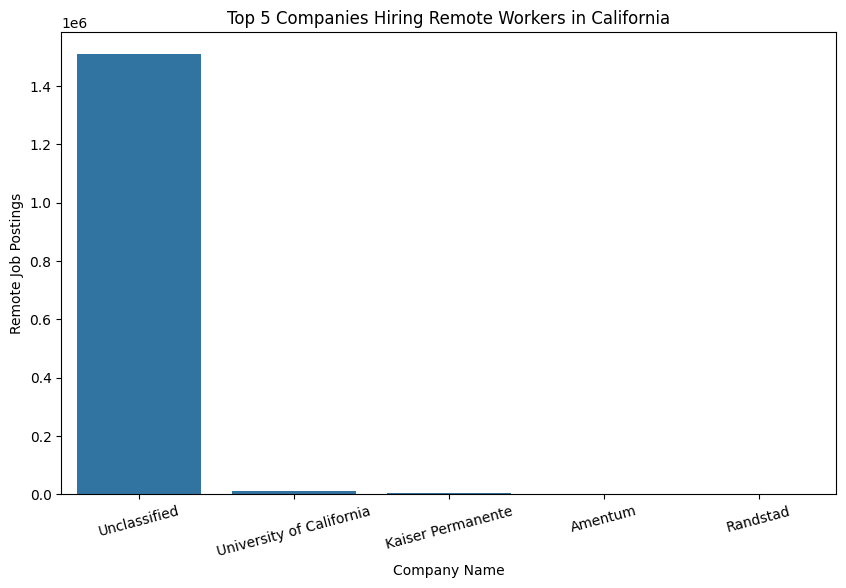

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=query2_pdf,
    x="company_name",
    y="remote_jobs"
)

plt.title("Top 5 Companies Hiring Remote Workers in California")
plt.xlabel("Company Name")
plt.ylabel("Remote Job Postings")

plt.xticks(rotation=15)

plt.show()

Though it may be skewed heavily towards unclassified, the number of remote opportunities at some of the largest hiring firms in the industry not having a very significant comparison to the smaller firms grouped together does give insight to how smaller firms likely utalize remote positions more than larger industry leaders

## Query 3 — Monthly Job Posting Trends in California

In [27]:
query3 = """
SELECT
    YEAR(try_to_timestamp(j.POSTED, 'M/d/yyyy')) AS year,
    MONTH(try_to_timestamp(j.POSTED, 'M/d/yyyy')) AS month,
    COUNT(*) AS job_count
FROM job_postings j
JOIN locations l
    ON j.LOCATION_ID = l.LOCATION_ID
WHERE
    l.STATE_NAME = 'California'
    AND try_to_timestamp(j.POSTED, 'M/d/yyyy') IS NOT NULL
GROUP BY
    YEAR(try_to_timestamp(j.POSTED, 'M/d/yyyy')),
    MONTH(try_to_timestamp(j.POSTED, 'M/d/yyyy'))
ORDER BY
    year DESC,
    month DESC
"""

In [28]:
query3_result = spark.sql(query3)

In [29]:
query3_result.show(20, truncate=False)

+----+-----+---------+
|year|month|job_count|
+----+-----+---------+
|2024|9    |2787841  |
|2024|8    |1834724  |
|2024|7    |1787680  |
|2024|6    |1954292  |
|2024|5    |1658115  |
+----+-----+---------+



In [30]:
query3_pdf = query3_result.toPandas()

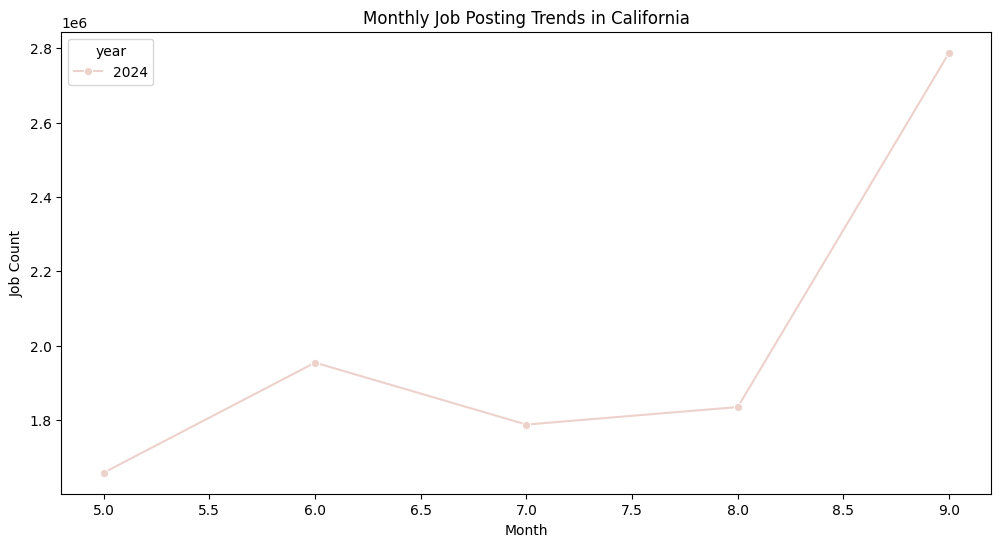

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.lineplot(
    data=query3_pdf,
    x="month",
    y="job_count",
    hue="year",
    marker="o"
)

plt.title("Monthly Job Posting Trends in California")
plt.xlabel("Month")
plt.ylabel("Job Count")

plt.show()

As the months go on, the number of job opporunites increases overall, with a significant rise in month 8 onward and slight dip between month 6 and 7. This showcases the economic patterns of the industry, as with more job counts in the later months, there likely is more economic activity and thus justification to hire more workers.

## Query 4 — Salary Comparisons Across Major US Cities

In [32]:
query4 = """
SELECT
    CASE
        WHEN l.MSA = '14460' THEN 'Boston'
        WHEN l.MSA = '47900' THEN 'Washington DC'
        WHEN l.MSA = '35620' THEN 'New York'
        WHEN l.MSA = '41860' THEN 'San Francisco'
        WHEN l.MSA = '42660' THEN 'Seattle'
        WHEN l.MSA = '31080' THEN 'Los Angeles'
        WHEN l.MSA = '19100' THEN 'Dallas'
        WHEN l.MSA = '26420' THEN 'Houston'
        WHEN l.MSA = '12420' THEN 'Austin'
        WHEN l.MSA = '34980' THEN 'Nashville'
        WHEN l.MSA = '28140' THEN 'Kansas City'
        WHEN l.MSA = '19740' THEN 'Denver'
    END AS metro_area,

    ROUND(AVG(j.SALARY), 2) AS avg_salary,

    COUNT(*) AS job_count

FROM job_postings j

JOIN locations l
    ON j.LOCATION_ID = l.LOCATION_ID

WHERE
    j.SALARY IS NOT NULL
    AND j.SALARY > 0
    AND l.MSA IN (
        '14460',
        '47900',
        '35620',
        '41860',
        '42660',
        '31080',
        '19100',
        '26420',
        '12420',
        '34980',
        '28140',
        '19740'
    )

GROUP BY
    l.MSA

ORDER BY
    avg_salary DESC
"""

In [33]:
query4_result = spark.sql(query4)

In [34]:
query4_result.show(truncate=False)

+-------------+----------+---------+
|metro_area   |avg_salary|job_count|
+-------------+----------+---------+
|Washington DC|135606.59 |2287790  |
|San Francisco|133712.35 |1336910  |
|Seattle      |127412.69 |655292   |
|Houston      |116758.83 |1402474  |
|Los Angeles  |115888.81 |1700450  |
|New York     |111576.76 |2143319  |
|Boston       |111506.67 |690133   |
|Nashville    |110872.23 |101198   |
|Austin       |110532.12 |2686063  |
|Dallas       |106088.88 |2264019  |
|Denver       |105159.8  |1686604  |
|Kansas City  |77262.74  |169339   |
+-------------+----------+---------+



In [35]:
query4_pdf = query4_result.toPandas()

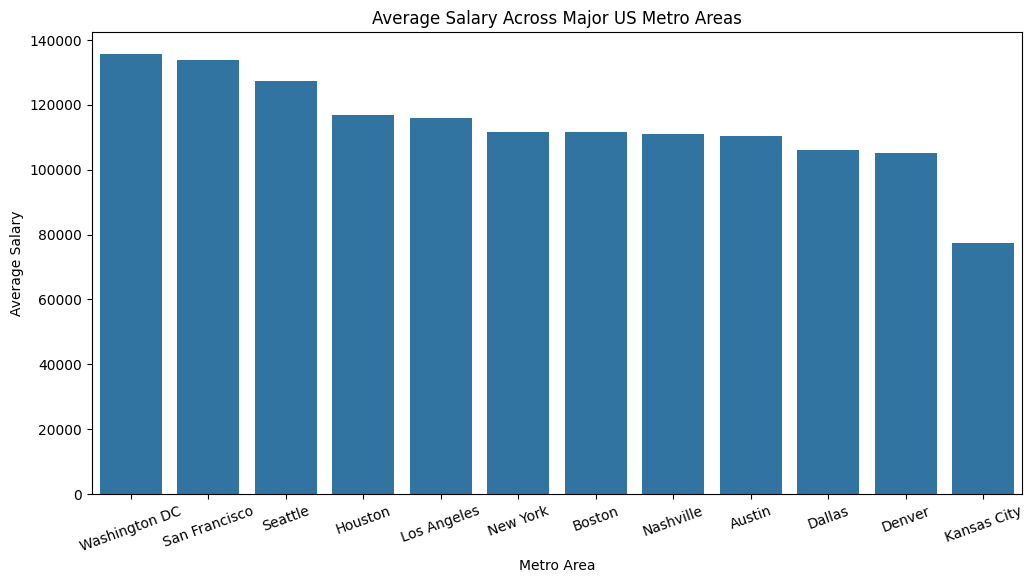

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=query4_pdf,
    x="metro_area",
    y="avg_salary"
)

plt.title("Average Salary Across Major US Metro Areas")
plt.xlabel("Metro Area")
plt.ylabel("Average Salary")

plt.xticks(rotation=20)

plt.show()

Again, most of the metro areas are relatively close to one another, however, it is clear that the predominently east and west coast areas have higher average salaries than otherwise. Houston is the one exception until Nashville of a non-east or non-west coast metro area being in the top 7, suggesting greater economic activity and opporunity in these regions.